### This project classifies CIFAR dataset using the following methods:
1. Baseline CNN
2. CNN with data augmentation
3. CNN with self supervised learning (SSL) - fine tuning and freeze options
4. CNN with SSL and 1 shot, 5 shots and 10 shots learning with fine tuning and freeze options

In [53]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

### Load CIFAR 10 dataset
The CIFAR-10 dataset is a foundational machine learning dataset consisting of 60,000 32x32 color images across 10 distinct classes, with 6000 images per class. It is divided into 50,000 training images and 10,000 test images. It has images of 10 classes, which are as follows:Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck. <br> x_train - numpy array of shape (50000, 32, 32, 3) - 3 colour channels <br> y_train - NumPy array containing the target "answers" for the images. Size: (50000, ), Values: Integers from 0 to 9, where each number represents a specific object class. 

In [56]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# Convert from uint8 (0–255) → float32 (0–1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
# Convert shape (N, 1) → (N,)
y_train = y_train.squeeze()
y_test = y_test.squeeze()
NUM_CLASSES = 10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1087s 6us/step


In [224]:
#Creating a log list to store values for each method for future comparison
log_list=[]

## 1. Normal classification using CNN 

### Training
The model contains the following layers
1. Convolution layers
Extract spatial features (edges → textures → shapes)
2. MaxPooling
Reduces spatial size, keeps important features
3. Dense layer
Learns final decision boundary
4. Softmax output
Converts logits → probabilities across 10 classes

In [227]:
model = keras.Sequential([
    
    # Block 1
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation="relu"),

    # Flatten + Dense
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(NUM_CLASSES, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

C:\Users\Anisha\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [228]:
#Training
import time

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",   
    patience=3,               # stop after 3 epochs of no improvement
    restore_best_weights=True
)

start_time = time.time()

history = model.fit(
    x_train, y_train,
    epochs=50,  
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

end_time = time.time()

log = {
    "method":"Baseline_CNN",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": history.history["val_accuracy"][-1],
}

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3665 - loss: 1.7079 - val_accuracy: 0.5035 - val_loss: 1.3741
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.5064 - loss: 1.3652 - val_accuracy: 0.5630 - val_loss: 1.2322
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.5703 - loss: 1.2146 - val_accuracy: 0.6182 - val_loss: 1.0731
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.6140 - loss: 1.0961 - val_accuracy: 0.6542 - val_loss: 0.9834
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.6448 - loss: 1.0129 - val_accuracy: 0.6463 - val_loss: 0.9847
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.6697 - loss: 0.9450 - val_accuracy: 0.6754 - val_loss: 0.9227
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.6933 - loss: 0.8798 - val_accuracy: 0.6880 - val_loss: 0.8731
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.7133 - loss: 0.8250 - 

In [229]:
#Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7236 - loss: 0.8490


## 2. CNN with data augmentation
Without augmentation, training may lead to memorization and overfitting. To avoid this, data augmentation can be used.

In [231]:
#Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
model = keras.Sequential([

    # Augmentation applied only during training
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation="relu"),

    # Head
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Anisha\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)           │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [232]:
#Training
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",   
    patience=3,               # stop after 3 epochs of no improvement
    restore_best_weights=True
)

start_time = time.time()

history = model.fit(
    x_train, y_train,
    epochs=50,  
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

end_time = time.time()

log = {
    "method":"CNN_data_augmentation",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": history.history["val_accuracy"][-1],
}

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3230 - loss: 1.8306 - val_accuracy: 0.4593 - val_loss: 1.4989
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4375 - loss: 1.5475 - val_accuracy: 0.5064 - val_loss: 1.3455
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.4818 - loss: 1.4492 - val_accuracy: 0.5231 - val_loss: 1.3669
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5133 - loss: 1.3744 - val_accuracy: 0.5907 - val_loss: 1.1543
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.5378 - loss: 1.3145 - val_accuracy: 0.5691 - val_loss: 1.2464
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.5548 - loss: 1.2662 - val_accuracy: 0.6045 - val_loss: 1.1201
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.5687 - loss: 1.2282 - val_accuracy: 0.6037 - val_loss: 1.1226
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.5786 - loss: 1.2030 - 

In [233]:
#Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6717 - loss: 0.9422


## 3. CNN with self supervised learning
Self-supervised learning (SSL) is a machine learning paradigm that trains models on unlabeled data by automatically generating supervisory signals from the data's inherent structure. The model learn representations by solving pretext tasks—such as predicting hidden parts of data—without manual human annotations.It reduces Labeling Costs, Leverages Abundant Data and in Better Representation. The goal is to learn general features
The idea is:<br>
1. Train CNN without labels on a self-supervised task.  Here the task chosen is predicting the rotations of the image
2. Reuse CNN as feature extractor
3. Train classifier with labels  - 2 options - fine tuning (where the entire network is trained on the input data after self supervised training - faster convergence of the model) and freezing (training only the classifier part on the input data). Freezing keeps pretrained features fixed and is effective in low-data settings, while fine-tuning allows the model to adapt to the task but requires more data and can risk overfitting.”

#### Training the network on self supervised task - image rotations

In [236]:
#Creating the dataset
def create_rotation_dataset(x):
    images = []
    labels = []

    for img in x:
        for k in range(4):
            rotated = np.rot90(img, k)
            images.append(rotated)
            labels.append(k)  # 0,1,2,3

    return np.array(images), np.array(labels)

x_ssl, y_ssl = create_rotation_dataset(x_train[:10000])  

#Creating the network
def build_encoder():
    inputs = keras.Input(shape=(32,32,3))
    x = layers.Conv2D(32, 3, activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    return keras.Model(inputs, x)

ssl_encoder = build_encoder()

#Training
inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(4, activation="softmax")(x)  # 4 rotations

ssl_model = keras.Model(inputs, outputs)

ssl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ssl_model.fit(x_ssl, y_ssl, epochs=50, batch_size=64)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3424 - loss: 1.3395
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4617 - loss: 1.2069
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5061 - loss: 1.1365
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5242 - loss: 1.1077
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5350 - loss: 1.0933
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5473 - loss: 1.0787
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5502 - loss: 1.0684
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5553 - loss: 1.0602
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5601 - loss: 1.0514
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5649 - loss: 1.0444
Epoch 11/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5673 - loss: 1.0380
Epoch 12/50
625/625 ━━━━━━━━━━

#### Classification using fine tuning

In [238]:
# Use pretrained encoder
ssl_encoder.trainable = True  

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",   
    patience=3,               # stop after 3 epochs of no improvement
    restore_best_weights=True
)

start_time = time.time()

history = classifier.fit(
    x_train, y_train,
    epochs=50,  
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

end_time = time.time()

log = {
    "method":"CNN_SSL_fine_tuning",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": history.history["val_accuracy"][-1],
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.3610 - loss: 1.7229 - val_accuracy: 0.4304 - val_loss: 1.5627
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4516 - loss: 1.5194 - val_accuracy: 0.4747 - val_loss: 1.4664
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.4818 - loss: 1.4417 - val_accuracy: 0.4867 - val_loss: 1.4195
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5023 - loss: 1.3966 - val_accuracy: 0.5098 - val_loss: 1.3746
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5168 - loss: 1.3612 - val_accuracy: 0.5251 - val_loss: 1.3584
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5255 - loss: 1.3338 - val_accuracy: 0.5221 - val_loss: 1.3373
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5357 - loss: 1.3101 - val_accuracy: 0.5496 - val_loss: 1.2940
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5408 - loss: 1.2886 - 

#### Classification using freezing the ssl encoder part in training

In [240]:
# Use pretrained encoder
ssl_encoder.trainable = False

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",   
    patience=3,               # stop after 3 epochs of no improvement
    restore_best_weights=True
)

start_time = time.time()

history = classifier.fit(
    x_train, y_train,
    epochs=50,  
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

end_time = time.time()

log = {
    "method":"CNN_SSL_Freeze",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": history.history["val_accuracy"][-1],
    
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3200 - loss: 1.9475 - val_accuracy: 0.4586 - val_loss: 1.5299
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4913 - loss: 1.4363 - val_accuracy: 0.5161 - val_loss: 1.3759
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5350 - loss: 1.3297 - val_accuracy: 0.5450 - val_loss: 1.3056
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5562 - loss: 1.2746 - val_accuracy: 0.5638 - val_loss: 1.2654
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5695 - loss: 1.2397 - val_accuracy: 0.5695 - val_loss: 1.2382
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5775 - loss: 1.2155 - val_accuracy: 0.5745 - val_loss: 1.2212
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5853 - loss: 1.1978 - val_accuracy: 0.5767 - val_loss: 1.2069
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5865 - loss: 1.1857 - val_accuracy: 0.

### 4. SSL with few shot learning
Enable models to learn new concepts or tasks from only a small number of labeled examples.

#### Create few shot dataset

In [243]:
NUM_CLASSES = 10

def create_few_shot(x, y, shots=5):
    x_fs, y_fs = [], []
    for c in range(NUM_CLASSES):
        idx = np.where(y == c)[0][:shots]
        x_fs.append(x[idx])
        y_fs.append(y[idx])
    return np.concatenate(x_fs), np.concatenate(y_fs)

x_5s, y_5s = create_few_shot(x_train, y_train, shots=5) #5 samples per class
x_1s, y_1s = create_few_shot(x_train, y_train, shots=1)#1 sample per class
x_10s, y_10s = create_few_shot(x_train, y_train, shots=10)#10 samples per class
x_20s, y_20s = create_few_shot(x_train, y_train, shots=20)#20 samples per class

##### SSL 1 shot learning with fine tuning

In [245]:
# Use pretrained encoder
ssl_encoder.trainable = True  #The ssl model created before is being used here as well.

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

history = classifier.fit(
    x_1s, y_1s, 
    epochs=50,  
    batch_size=64,
    
)

end_time = time.time()

log = {
    "method":"CNN_1s_SSL_fine_tuning",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": -1,#Not calculated because validation split reduces training data
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1000 - loss: 7.2322
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1000 - loss: 6.6956
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1000 - loss: 6.1939
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1000 - loss: 5.7260
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1000 - loss: 5.2927
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1000 - loss: 4.8942
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.0000e+00 - loss: 4.5321
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0000e+00 - loss: 4.2063
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.0000e+00 - loss: 3.9166
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1000 - loss: 3.6626
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1000 - loss: 3.4408
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1000 - loss

##### SSL 1 shot learning with freezing

In [247]:
# Use pretrained encoder
ssl_encoder.trainable = False  #The ssl model created before is being used here as well.

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

history = classifier.fit(
    x_1s, y_1s, 
    epochs=50,  
    batch_size=64,
    
)

end_time = time.time()

log = {
    "method":"CNN_1s_SSL_freeze",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": -1,
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step - accuracy: 0.0000e+00 - loss: 3.4025
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1000 - loss: 3.3339
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1000 - loss: 3.2675
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1000 - loss: 3.2037
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1000 - loss: 3.1425
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1000 - loss: 3.0842
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1000 - loss: 3.0288
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1000 - loss: 2.9761
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1000 - loss: 2.9261
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1000 - loss: 2.8786
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1000 - loss: 2.8333
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1000 - loss: 2.7

##### SSL 5 shot learning with fine tuning

In [249]:
# Use pretrained encoder
ssl_encoder.trainable = True  #The ssl model created before is being used here as well.

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

history = classifier.fit(
    x_5s, y_5s, 
    epochs=50,  
    batch_size=64,
    
)

end_time = time.time()

log = {
    "method":"CNN_5s_SSL_fine_tuning",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": -1
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1400 - loss: 3.9771
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1400 - loss: 3.6513
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1600 - loss: 3.3741
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1600 - loss: 3.1450
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1200 - loss: 2.9601
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1200 - loss: 2.8127
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0800 - loss: 2.6942
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.1000 - loss: 2.5979
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.1000 - loss: 2.5176
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.1200 - loss: 2.4484
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.1000 - loss: 2.3872
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.1000 - loss: 2.332

In [250]:
##### SSL 5 shot learning with freezing

In [251]:
# Use pretrained encoder
ssl_encoder.trainable = False  #The ssl model created before is being used here as well.

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

history = classifier.fit(
    x_5s, y_5s, 
    epochs=50,  
    batch_size=64,
    
)

end_time = time.time()

log = {
    "method":"CNN_5s_SSL_freeze",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": -1,
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step - accuracy: 0.0400 - loss: 3.5600
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0400 - loss: 3.5072
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0400 - loss: 3.4565
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.0400 - loss: 3.4079
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0400 - loss: 3.3613
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0400 - loss: 3.3168
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0200 - loss: 3.2742
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0200 - loss: 3.2336
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0200 - loss: 3.1949
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0200 - loss: 3.1579
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0400 - loss: 3.1227
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0400 - loss: 3.0891


##### SSL 10 shot learning with fine tuning

In [253]:
# Use pretrained encoder
ssl_encoder.trainable = True  #The ssl model created before is being used here as well.

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

history = classifier.fit(
    x_10s, y_10s, 
    epochs=50,  
    batch_size=64,
    
)

end_time = time.time()

log = {
    "method":"CNN_10s_SSL_fine_tuning",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": -1,
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.0900 - loss: 3.9685
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1600 - loss: 3.4099
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1500 - loss: 3.0496
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1400 - loss: 2.8080
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1400 - loss: 2.6461
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1500 - loss: 2.5397
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1600 - loss: 2.4293
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1700 - loss: 2.3501
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1400 - loss: 2.2705
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1500 - loss: 2.2085
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1900 - loss: 2.1512
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2300 - loss: 2.0991
E

##### SSL 10 shot learning with freezing

In [255]:
# Use pretrained encoder
ssl_encoder.trainable = False  #The ssl model created before is being used here as well.

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

history = classifier.fit(
    x_10s, y_10s, 
    epochs=50,  
    batch_size=64,
    
)

end_time = time.time()

log = {
    "method":"CNN_10s_SSL_freeze",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": -1,
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1100 - loss: 3.4185 
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1000 - loss: 3.3042
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1000 - loss: 3.1961
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1000 - loss: 3.1043
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1100 - loss: 3.0059
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1300 - loss: 2.9348
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1200 - loss: 2.8629
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1100 - loss: 2.7983
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1100 - loss: 2.7372
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1200 - loss: 2.6884
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1300 - loss: 2.6421
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1400 - loss: 2.5971


#### 20 shot SSL with fine tuning

In [257]:
# Use pretrained encoder
ssl_encoder.trainable = True  #The ssl model created before is being used here as well.

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

history = classifier.fit(
    x_20s, y_20s, 
    epochs=50,  
    batch_size=64,
    
)

end_time = time.time()

log = {
    "method":"CNN_20s_SSL_fine_tuning",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": -1,
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.1350 - loss: 5.5490
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1450 - loss: 4.3373
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1500 - loss: 3.5787
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1600 - loss: 3.1338
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1550 - loss: 2.8325
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1550 - loss: 2.6651
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1250 - loss: 2.5422
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1250 - loss: 2.4407
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1250 - loss: 2.3638
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1350 - loss: 2.2923
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1550 - loss: 2.2356
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1650 - loss: 2.1860
E

#### 20 shot ssl with freezing

In [259]:
# Use pretrained encoder
ssl_encoder.trainable = False  #The ssl model created before is being used here as well.

inputs = keras.Input(shape=(32,32,3))
x = ssl_encoder(inputs)
outputs = layers.Dense(10, activation="softmax")(x)

classifier = keras.Model(inputs, outputs)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


start_time = time.time()

history = classifier.fit(
    x_20s, y_20s, 
    epochs=50,  
    batch_size=64,
    
)

end_time = time.time()

log = {
    "method":"CNN_20s_SSL_freeze",
    "final_epochs_run": len(history.epoch),
    "batch_size": 64,
    "training_time_sec": end_time - start_time,
    "final_train_acc": history.history["accuracy"][-1],
    "final_val_acc": -1,
}

#Evaluation
test_loss, test_acc = classifier.evaluate(x_test, y_test)
#Storing the log dict in the log list
log["test_accuracy"] = test_acc
log["test_loss"] = test_loss
log_list.append(log)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0700 - loss: 3.2691 
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0700 - loss: 3.1126
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0750 - loss: 2.9928
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0800 - loss: 2.8877
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0800 - loss: 2.7988
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0850 - loss: 2.7261
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0900 - loss: 2.6582
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1050 - loss: 2.5979
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1100 - loss: 2.5490
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1000 - loss: 2.5020
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1100 - loss: 2.4613
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1150 - loss: 2.4232


## Comparative Analysis

In [261]:
#Conerting log_list to pandas dataframe for plotting
import pandas as pd

df = pd.DataFrame(log_list)
print(df)

                     method  final_epochs_run  batch_size  training_time_sec  \
0              Baseline_CNN                16          64         326.109762   
1     CNN_data_augmentation                18          64         468.056050   
2       CNN_SSL_fine_tuning                21          64         290.494997   
3            CNN_SSL_Freeze                44          64         236.036992   
4    CNN_1s_SSL_fine_tuning                50          64           4.772820   
5         CNN_1s_SSL_freeze                50          64           3.575363   
6    CNN_5s_SSL_fine_tuning                50          64           7.973917   
7         CNN_5s_SSL_freeze                50          64           4.386692   
8   CNN_10s_SSL_fine_tuning                50          64           6.110998   
9        CNN_10s_SSL_freeze                50          64           4.588634   
10  CNN_20s_SSL_fine_tuning                50          64           7.918998   
11       CNN_20s_SSL_freeze             

In [293]:
#Splitting few shot and full data results
df_few = df.loc[df["method"].str.contains("1s|5s|10s|20s")]
df_full = df.loc[~df["method"].str.contains("1s|5s|10s|20s")]

### 1. Test Accuracy comparison for full data

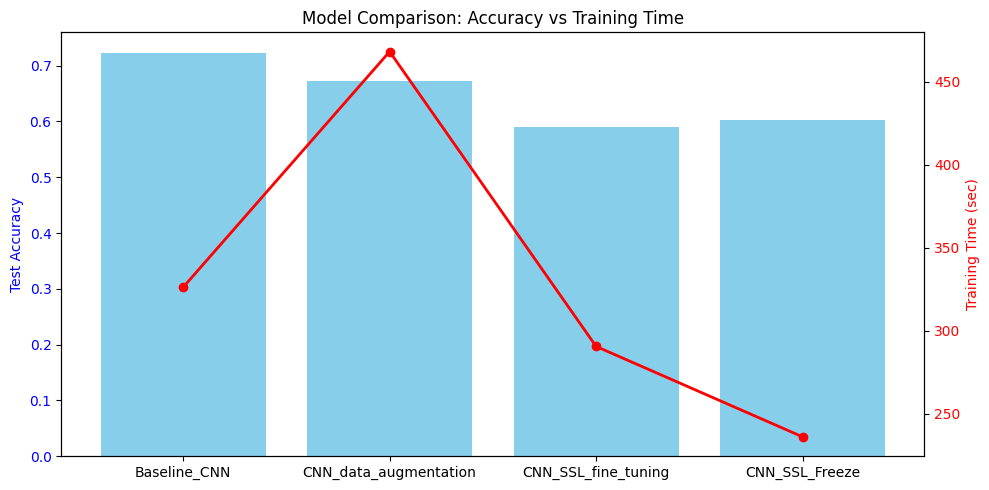

In [340]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

# Bar plot → Test Accuracy
bar=ax1.bar(df_full["method"], df_full["test_accuracy"], color="skyblue")
ax1.set_ylabel("Test Accuracy", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# Second axis → Training Time
ax2 = ax1.twinx()
ax2.plot(df_full["method"], df_full["training_time_sec"], 
         color="red", marker="o", linewidth=2)
ax2.set_ylabel("Training Time (sec)", color="red")
ax2.tick_params(axis='y', labelcolor="red")

# Formatting
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison: Accuracy vs Training Time")

plt.tight_layout()
plt.show()

### 2. Number of epochs comparison for full data

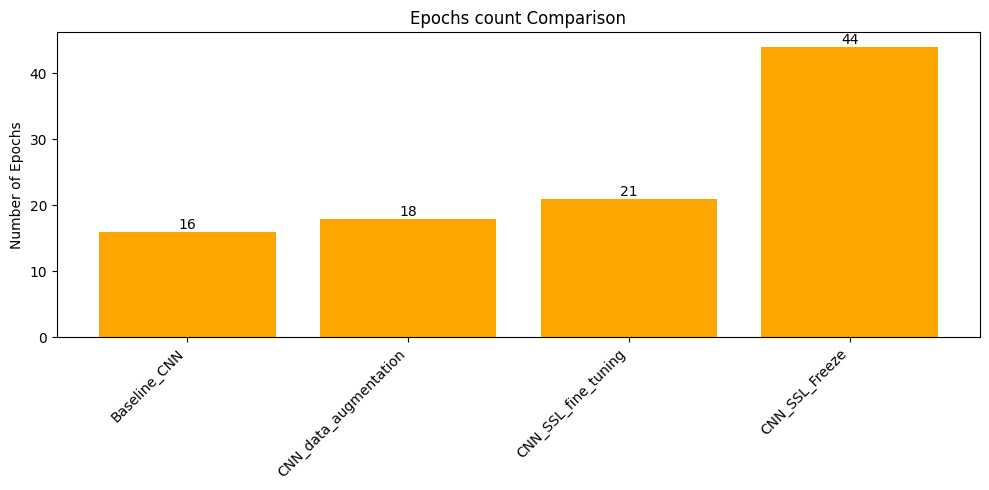

In [330]:
plt.figure(figsize=(10,5))

bar=plt.bar(df_full["method"], df_full["final_epochs_run"], color="orange")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Epochs")
plt.title("Epochs count Comparison")
plt.bar_label(bar, label_type='edge')
plt.tight_layout()
plt.show()

### 3. Train vs validation vs test accuracy for full data

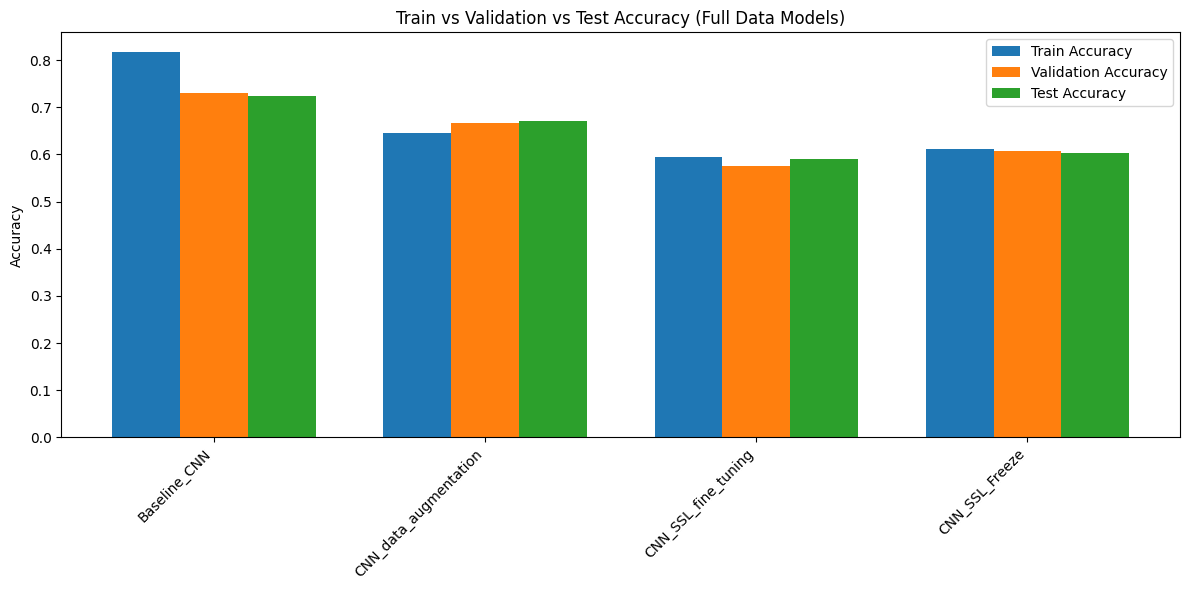

In [318]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(df_full["method"]))  # positions
width = 0.25  # bar width

plt.figure(figsize=(12,6))

# Train
plt.bar(
    x - width,
    df_full["final_train_acc"],
    width,
    label="Train Accuracy"
)

# Validation
plt.bar(
    x,
    df_full["final_val_acc"],
    width,
    label="Validation Accuracy"
)

# Test
plt.bar(
    x + width,
    df_full["test_accuracy"],
    width,
    label="Test Accuracy"
)

plt.xticks(x, df_full["method"], rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Train vs Validation vs Test Accuracy (Full Data Models)")
plt.legend()

plt.tight_layout()
plt.show()

### 4. Accuracy plot for few shot learning

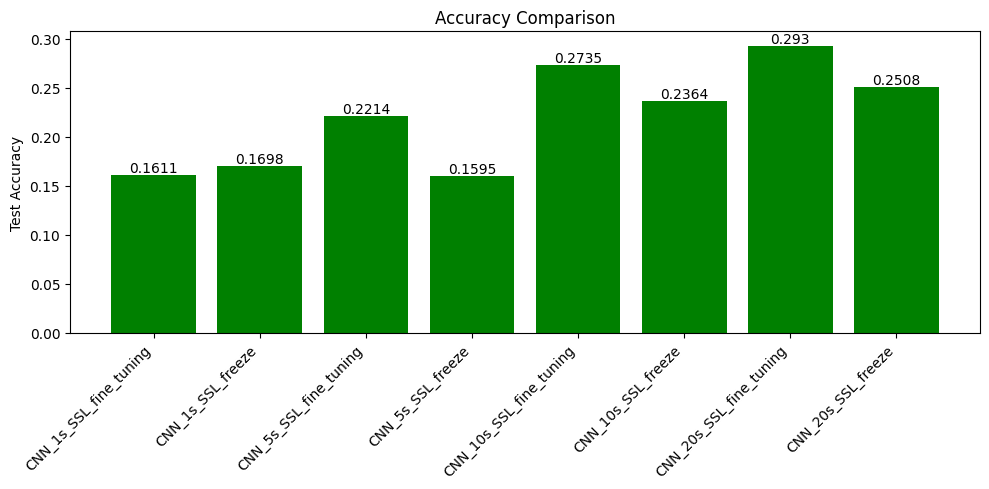

In [328]:
plt.figure(figsize=(10,5))

bar=plt.bar(df_few["method"], df_few["test_accuracy"], color="green")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Accuracy Comparison")
plt.bar_label(bar, label_type='edge')
plt.tight_layout()
plt.show()


### 5. Training time comparison

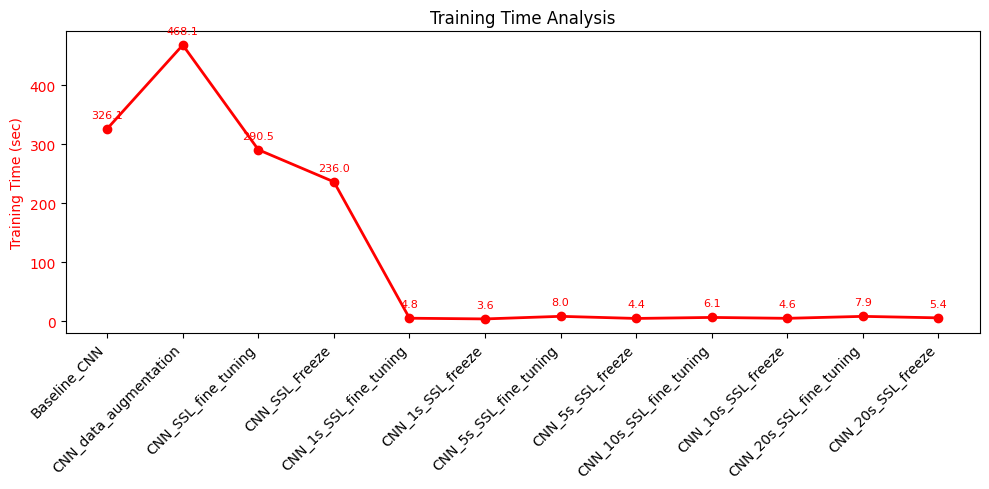

In [345]:
fig, ax2 = plt.subplots(figsize=(10,5))
ax2.plot(df["method"], df["training_time_sec"], 
         color="red", marker="o", linewidth=2)
ax2.set_ylabel("Training Time (sec)", color="red")
ax2.tick_params(axis='y', labelcolor="red")
for i, txt in enumerate(df["training_time_sec"]):
    ax2.annotate(
        f"{txt:.1f}",
        (i, df["training_time_sec"].iloc[i]),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        color="red",
        fontsize=8
    )
# Formatting
plt.xticks(rotation=45, ha="right")
plt.title("Training Time Analysis")

plt.tight_layout()
plt.show()